# Neural Network Representation

In the first two weeks of the course, we focused on the important machine learning foundations of Linear Regression and Logistic Regression. Both are data modelling techniques that have been used extensively in statistics and machine learning for decades. They are powerful, relatively easy to understand, and applicable to a surprisingly wide range of problems.

This week, we will explore how linear and logistic functions serve as the fundamental building blocks of Deep Neural Networks.

## Preliminaries
We begin by reintroducing some functions from our Logistic Regression and Linear Regression notes.

In [1]:
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def standardize(x):
    col_means = np.mean(x,axis=0)
    col_std = np.std(x,axis=0)
    return (x - col_means) / col_std , col_means, col_std

def h_linear(theta,X):
    z = np.matmul(theta,X)
    return z

def h_logistic(theta,X):
    z = np.matmul(theta,X)
    return 1 / (1 + np.exp(-z))

def cost_logistic(theta,xi,yi):
    # note - this function calculate the cost for all variations of theta. A vector is returned.
    z = np.matmul(theta,xi)
    h = 1 / (1 + np.exp(-z))
    if yi == 1:
        return -np.log(h)
    elif yi == 0:
        return -np.log(1-h)
    else: raise ValueError('yi was neither 0 nor 1: ' + str(yi))

def cost_linear(theta,xi,yi):
    # note - this function calculate the cost for all variations of theta. A vector is returned.
    z = np.matmul(theta,xi)
    h = 1 / (1 + np.exp(-z))
    rv = ((h - yi)**2) / 2
    return rv

def J(theta,x,y,f):
    s = 0
    m = len(x)
    for i in range(0,m):
        v = f(theta,x[i],y[i])
        s+= v
    return s / m

def gd(theta_in,min_delta_in,a_in,X_in,Y_in,h,maxiterations=-1,cost=cost_logistic):
    m = len(Y_in) # number of training examples
    _ , n = np.shape(X_in) # number of features

    # define a list used to store the costs - these do not have to be calculated but are useful for debugging
    c = []

    # Create a theta variable which we will use to keep track of the current value of theta
    theta = theta_in

    # Create a list which we will use for storing theta results during optimization
    thetas = np.array(theta_in,ndmin=2)

    # Create a counter which is used for limiting the number of iterations used if maxiterations has been defined
    k = 0

    # Begin main search loop
    while maxiterations == -1 or k < maxiterations:
        k+=1
        c.append(J(theta_in,X_in,Y_in,cost))

        temp = np.copy(theta)
        for j in range(0,n):
            # making calculations for jth parameter
            s = 0
            for i in range(0,m):
                s+=  (h(temp.T,np.ravel(X_in[i,:])) - Y_in[i])  * X_in[i,j]
            theta[j] = temp[j] - a_in * (1/m) * s
        thetas = np.vstack((thetas,theta))

        progressing = False
        for j in range(0,n):
            if(abs(temp[j] - theta[j]) > min_delta_in):
                progressing = progressing | True
        if not progressing: break
    return thetas, c

## Motivation: From Linear to Non-Linear Model Learning

Both Linear Regression and Logistic Regression are fundamentally linear models. That is, the hypotheses they produce are based on linear combinations of input features.

When the true structure in the data is more complex than a linear model can capture, we can “cheat” by manually introducing nonlinear feature transformations (e.g., polynomial features) and feeding those into the linear model. This is exactly what we did when we introduced higher-order features in our earlier examples of Linear and Logistic Regression.

The problem with this approach is that it does not scale well. To achieve complex nonlinear decision boundaries in a classification problem, we may need to add many additional features. If we introduce quadratic or higher-order polynomial terms, the number of features can grow combinatorially (and potentially exponentially) with the number of base features.

Neural Networks allow us to construct nonlinear models without manually encoding higher-order features. Instead, the network learns useful feature transformations as part of its training process. The advantage of this approach is that we do not have to guess which higher-order features might be useful — the network learns representations that improve predictive performance.

The main disadvantage of neural networks is computational cost. They are typically orders of magnitude more expensive to train than logistic regression models — even when those models include many manually engineered features. From the mid-1990s to the early 2010s, this high computational cost limited their practical use. However, advances in hardware (especially GPUs) and algorithmic improvements have allowed neural networks to finally realize their potential.


## Logistic Units

Neural networks are composed of simple computational units called neurons. While inspired loosely by biological neurons, artificial neurons are mathematical functions that compute an output based on their inputs. Individually, they are simple; when arranged into layered architectures and trained using powerful optimization algorithms, they can model highly complex nonlinear relationships.

Many types of neurons exist, distinguished primarily by their activation functions. We begin with one of the most important: the logistic unit (also called the sigmoid neuron).

A logistic unit is based on logistic regression. It produces an output by applying the logistic (sigmoid) function to a linear combination of inputs:


$$
z = \theta^{T} x
$$

$$
h_{\theta}(x) = \frac{1}{1 + e^{-z}}
$$

where:

- $x$ is the input feature vector  
- $\theta$ is the parameter vector  
- $z$ is the linear combination (the **logit**)  
- $h_{\theta}(x)$ is the hypothesis (output of the logistic unit)


In the above equations, $\theta$ represents the model parameters, $x$ is the input feature vector, and $h_\theta(x)$ is the output of the function, commonly referred to as the **hypothesis**.

The quantity

$$
z = \theta^T x
$$

is the linear combination (dot product) of the parameters and input features. This value is often referred to as the **logit**.

We interpret the logistic function as:

$$
h_\theta(x) = P(Y = 1 \mid x, \theta)
$$

That is, the output of the logistic unit represents the estimated probability that $Y = 1$ given the input features and model parameters.

To obtain a classification decision, we apply a threshold to $h_\theta(x)$ (commonly 0.5).

---

As mentioned, there are many different types of neurons. The most significant difference between neuron types lies in their **activation function**, which determines how the linear combination $z$ is transformed into an output.

In this case, the activation function is the **logistic (sigmoid) function**. However, other activation functions can be used. For example, a **linear activation function** produces a continuous real-valued output, which is useful in regression settings.

---

### Example

Consider a classifier with two input features:

- $x_1$: number of years since a truck part was replaced  
- $x_2$: distance traveled (in kilometers) since the last inspection  

Let the target variable $Y$ indicate whether the part is faulty following inspection.

A logistic unit can combine $x_1$ and $x_2$ linearly, apply the logistic activation function, and output the probability that the part is faulty.


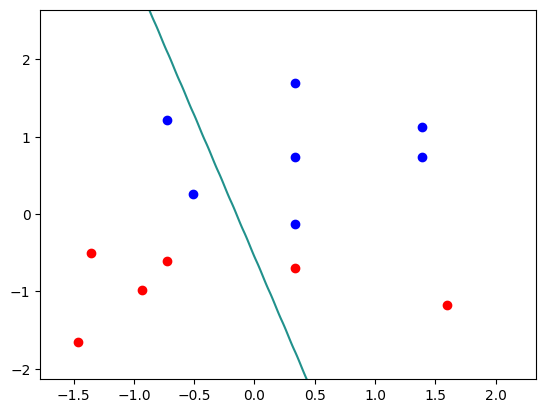

In [2]:
# Define the target values
Y =  [0,0,0,0,0,1,0,1,1,1,1,1,1]

# Define the 2 input features in a instance wise fashion
X = np.array([[0.3,50000],
              [3.2,100000],
              [0.4,170000],
              [0.8,120000],
              [2,150000],
              [1.2,250000],
              [1.0,160000],
              [2,210000],
              [2,300000],
              [2,400000],
              [3,300000],
              [3,340000],
              [1,350000]
             ])

# standardize our input data
X, means, stds = standardize(X)

# Define the function parameters - these were figured out using gradient descent (not shown here)
#theta = [3.6,2.6,11]
theta = [1.54092103, 10.25393618, 2.8042716 ]

# initialize values for features x1 and x2
x1_range = np.arange(0,4,0.1)
x2_range = np.arange(0.0,500000,1000.0)

x1s, x2s = np.meshgrid(x1_range, x2_range) # remember - plt.surface likes this meshgrid output
mesh_rows, mesh_cols = x1s.shape

# construct 1D arrays for x1, x2 and x0
x1 = np.ravel(x1s)
x2 = np.ravel(x2s)
x = np.vstack((x1,x2)).T

# rescale our data based on our normalization parameters
x =  (x-means)/stds

# define the new matrix X based around our standardized vector for X previously obtained
x_0 = np.array([1]*len(x2))
x = np.hstack((x_0[:, np.newaxis],x))

# perform calculations
z = h_logistic(theta,x.T)

# reshape result to have the same organization as result of meshgrid
zs = np.reshape(z,(mesh_rows,mesh_cols))
x1s = np.reshape(x[:,1],(mesh_rows,mesh_cols))
x2s = np.reshape(x[:,2],(mesh_rows,mesh_cols))

for l in range(len(Y)):
    if Y[l] == 0:
        plt.plot(X[l,0],X[l,1],'o',c='r')
    elif Y[l] == 1:
        plt.plot(X[l,0],X[l,1],'o',c='b')
    else: print(Y[l])

plt.contour(x1s, x2s, zs, 1)
plt.show()

A logistic neuron is simply a different architectural perspective on the logistic function. Structurally an artificial neuron has the following components:
 * A set of inputs x - these are the values that are fed into the neuron
 * A set of weights w - each weight $w_{i}$ can be interpreted as the relative strength (positive or negative) that we assign to an individual input value $x_{i}$
 * A cell body which computes the output for this neuron - the cell body can compute different types of outputs. For our purposes here we assume the output is a logistic function over the inputs x and the weights w.
 * An output which holds the computed logistic function

We can illustrate this structure with respect to our faulty truck part classifier with the figure below.

<!-- neurons.png -->
<img width="300" src="https://drive.google.com/uc?id=1tTxdiEk3I8G4RimXnGjTSOyD0V7O0hXe">


As previously described, in logistic regression we appended a vector of 1s to our input data array X in order to facilitate a vectorized implementation of linear functions. The same is accomplished in the architecture of the neuron through the addition of the **bias unit** which:
 1. is always assumed to have a value = 1
 2. Is usually referenced as the $0^{th}$ input unit to the neuron.  

In the example above we draw in the bias unit and weights explicitly, but it is important to note that in drawings we usually omit the bias unit and often the values for weights. Thus the example above would more normally be drawn as shown below.

<!-- neurons2.png -->
<img width="300" src="https://drive.google.com/uc?id=1exVVPlJ3VfGW-nVKBr8dhA-o4kNZboyZ">

## Combining Logistic Units
Logistic units can be combined to implement more complex functions. We can examine this by looking at the design of individual binary operations, and then the combination of these units to achieve more sophisticated operations.

### AND Units

Consider first the construction of the simple AND operator defined over two variables x1 and x2. The desired logic for an AND operation is defined as follows:

x1 | x2 | x1 AND x2
--- | --- | :---:
0 |	0 |	0
0 |	1 |	0
1 |	0 |	0
1 | 1 | 1

where x1, x2 and are result are all binary values.

It is relatively easy to find the parameters for a logistic unit which will result in computing an AND function. Such a unit (illustrated fully with bias units and weights) is illustrated below.

<!-- and.png -->
<img width="300" src="https://drive.google.com/uc?id=1DCfzkxXemiEP-BzdGdI3lEWD1gDZbNk9">

Noting that the value for $x0 = 1$ and $x1,x2 \in \{0,1\}$, we see that the parameter on the bias unit pushes the scalar product of inputs and parameters to a minimum value of -30. The only way this scalar sum of inputs and weights can go above 1 is if both the inputs x1 and x2 are 1. This is summarized in the table below:

x1 | x2 | $\theta x$ | h($\theta$ x)
--- | --- | :---: | :---:
0 |	0 |	-30 | 0
0 |	1 |	-10 | 0
1 |	0 |	-10 | 0
1 | 1 | 10  | 1

Note that the values of h are actually rounded a little bit. You can see the actual values below and tweak the parameters below.

In [3]:
def h_log(z):
    return 1 / (1 + np.exp(-z))

def calc(x1,x2,theta0,theta1,theta2):
    x0 = 1
    z = x0*theta0 + x1*theta1 + x2*theta2
    h = h_log(z)
    return z, h

# parameters for AND approximation
theta0 = -30
theta1 = 20
theta2 = 20

z, h = calc(0,0,theta0,theta1,theta2)
print(str(z) + " " + str(h))

z, h = calc(0,1,theta0,theta1,theta2)
print(str(z) + " " + str(h))

z, h = calc(1,0,theta0,theta1,theta2)
print(str(z) + " " + str(h))

z, h = calc(1,1,theta0,theta1,theta2)
print(str(z) + " " + str(h))

-30 9.357622968839299e-14
-10 4.5397868702434395e-05
-10 4.5397868702434395e-05
10 0.9999546021312976


### OR Units

Similarly the OR operator can be defined over two binary variables $x1$ and $x2$. The logic for the OR operator is summarized below:

x1 | x2 | x1 OR x2
--- | --- | :---:
0 |	0 |	0
0 |	1 |	1
1 |	0 |	1
1 | 1 | 1

By choosing appropriate weights for a logistic unit we can once again achieve the desired logic as illustrated below.

<!-- or.png -->
<img width="300" src="https://drive.google.com/uc?id=197c9_5krm_XLwga-wtFL9FWvEPiL3bNN">

Here the bias unit only partly pushes the scalar product of inputs and parameters below 1. In the case of either or both x1 and x2 being set to 1, the total scalar product will be greater than 0 with the result being that the logistic function has a total output 1. This can be illustrated in the table below.

x1 | x2 | $\theta x$ | h($\theta$ x)
--- | --- | :---: | :---:
0 |	0 |	-10 | 0
0 |	1 |	10  | 1
1 |	0 |	10  | 1
1 | 1 | 30  | 1

### NOT Units

The final atomic unit we will consider is the NOT unit. The NOT unit takes only one explicit input $x1$ and returns the negation of the value on that input as summarized below:

x1 | NOT x1
--- | :---:
0 |	1
1 |	0

A logistic unit which simulates the behaviour of a NOT operation when applied to binary values is illustrated below.

<!-- not.png -->
<img width="300" src="https://drive.google.com/uc?id=1FIsJtcJWKkDDXcXuKTvxWKKGB54ITkOn">

Here when x1 is set the 0, the effect of the bias unit with its weight will be to force the scalar product $\theta x$ to be greater than 0. However if $x1=1$ the strong negative value of the weight on $x2$ will lead the scalar product $\theta x$ to be less than 0. This is summarized in the table below.

x1  | $\theta x$ | h($\theta$ x)
--- | :---:      | :---:
0   |     10      |        1
1   |    -10      |        0

### XNOR Units

Given the AND, OR, and NOT units defined above we can implement more sophisticated functions based on those units. To illustrate let us consider the XNOR operation which is defined with the following truth table:

x1 | x2 | x1 XNOR x2
--- | --- | :---:
0 |	0 |	1
0 |	1 |	0
1 |	0 |	0
1 | 1 | 1

XNOR requires both values $x1$ and $x2$ to have the same inputs. The XNOR operation may be defined in terms of our 3 fundamental operations as follows:

\begin{equation}
x1\; XNOR\; x2 = (x1\; AND\; x2)\; OR\; ((NOT\; x1)\; AND\; (NOT\; x2))
\end{equation}

By allowing the outputs of some units to act as inputs to another units we can implement the above equation with logistic units as follows:

<!-- xnor.png -->
<img width="400" src="https://drive.google.com/uc?id=1ZaFKNLuRPsaCWQd8jLey6YuQRAPFR8uo">

We can use logistic (sigmoid) units to construct simple binary functions such as AND, OR, and NOT. By layering these units on top of one another, we can combine simple functions to build more complex ones.

Constructing an XNOR unit is just a basic illustration of this principle. As we add more layers and more units, neural networks become capable of representing increasingly complex functions — complex enough to recognize images, understand speech, and process language.

However, the XNOR example we built was handcrafted. In practice, we do not manually design these weights. Instead, we use learning algorithms to automatically discover the appropriate weights from data.

## The Architecture of a Neural Network

Neural networks are built by connecting logistic units (or other types of neurons) in layers. The XNOR example we saw earlier illustrates many key principles of standard neural networks. We will first focus on the Feedforward Neural Network (FFNN) built exclusively from logistic units. FFNN is one type of architecture where information only flows in one direction, input → hidden → output. Typically, nodes in one layer are connected to all nodes in the next layer, but the defining feature of this architecture is, it is he forward-only, acyclic flow of information.


### Layers of the Network

A Feedforward Neural Network consists of at least three layers:
- Input Layer – Receives the input data vector $x$.
- Hidden Layers – Encode higher-order features and transformations of the input. One or more hidden layers can be found between the input and output layers. The hidden layers encode higher order features which operate over the input data which transform the data prior to the final classification at the output layer.
- Output Layer – Produces the network's final prediction $y$, captures the result of our model.


<!-- ffnn.png -->
<img width="400" src="https://drive.google.com/uc?id=1rJmU_M7PJXP2bdnp9z0vQho30d-bGcFo">

In a typical fully connected FFNN, each node in layer $j$ is connected to all nodes in the previous layer $j-1$ through weights. The input layer is an exception: it has no incoming connections and simply provides the input data to the network. These weights function like the parameters in linear or logistic regression, controlling how input signals are transformed as they propagate through the network.


### Multi-class Classification

In the example above we have only one neuron in the output layer but there can be many more in practice to model multi class classification. Therefore, for multi-class problems, the output layer can have multiple neurons. For example in the larger network below, there are three output units.

<!-- ffnn2 -->
<img width="400" src="https://drive.google.com/uc?id=1Y0ygTfRpK3busG8AaNwKWbRKpMAy_Hse">

Each neuron in this architecture acts as a binary classifier for a single class. This means that we can build 3 binary classifiers in parallel. This gives us our normal way of handling multi-class classification problems. For a target, e.g., animal type, with 3 classes, e.g., dog, cat and hamster, we create a binary output unit for each of those 3 types. In training the network on a multi-class classification problem we expect only one output unit to be active at a time. During classification we ideally want only one output unit to be active, but in practice most will have some activity and we select the output node that has the highest activity as our hypothesised class. This is referred to as the **One versus All** method.

### Bias Units

Each layer (except the output layer) typically has a bias unit. The bias unit in layer $j$ is not connected to units in the previous layer $j-1$; instead, it provides a fixed input of 1 to the units in the next layer. This allows the neurons to shift their activation function, analogous to the intercept term in linear or logistic regression. In the illustration below, we include the bias unit to show its role in the network.

<!-- ffnn3 -->
<img width="400" src="https://drive.google.com/uc?id=1fEpYM3W71k0K5MYyvaoJ9kKEkG_z75g7">


### Deep Networks

Deep Feedforward Neural Networks are simply defined as Feedforward Networks that have more than one hidden layer. For example even this simple model below would be technically referred to as a Deep Network:

<!-- dnn.png -->
<img width="400" src="https://drive.google.com/uc?id=1sKKBvo8dMyJbk6aJ1FmNOYuLpgZuzCrr">



Although more typically our networks will in practice have many more nodes at each layer and a number of hidden layers.


<!-- dnn2.png -->
<img width="400" src="https://drive.google.com/uc?id=1ybpKrMKhxHDqpGnuvH0nZbuABHU2G-lH">

## Notational Conventions

When working through descriptions of neural network one of the most challenging problems is keeping track of the notation - particularly with respect to indexing through multiple layers of the network and multiple training and testing examples.

### Notation for Data
As with any other supervised machine learning method, our model is trained with a set of m input-output tuples:

\begin{equation}
Data_{Training} = \{ (x^{0},y^{0}),(x^{1},y^{1}),(x^{2},y^{2})\dots (x^{m-1},y^{m-1}) \}
\end{equation}

Each tuple is an individual training case which we index with a superscript.

For each individual training case we assume vectorized inputs and outputs. The length of an input vector must be equal to the number of units on the input layer (not counting the bias unit). Similarly the length of an output vector must be equal to the number of units on the output layer of the network. Thus for a network with 3 input units and 2 output units:

$$
x^i \in \mathbb{R}^{3 \times 1}, \quad y^i \in \mathbb{R}^{2 \times 1}
$$


### Notation for Layers
A neural network is built out of a number of layers. A layer typically includes both the nodes and a set of associated weights. In indexing and describing the layers of an individual network we use the following notation:
 * $L$ - the total number of layers in the network
 * $s_{l}$ - the number of nodes in the $l^{th}$ layer of the network - excluding bias units.

In many sources our first layer is indexed as layer 1 rather than layer 0. However this only makes the programming of these networks more cumbersome. Here we will stick with standard computer science convention of indexing from 0. Hence:
- layer $0$ = input layer,
- layer $1, 2, 3, ..(L-2)$ = hidden layers,
- layer $L-1$ = output layer.

#### Notation for Nodes

Each layer includes a set of activation units. We rarely index the units themselves. Instead we index the values produced at those units. We refer to the output of a node as its activation value. For the first layer the activation value for a given unit is simply the corresponding input value from the data. For all other layers the activation value for a unit is its computed output. For logistic units, this is the logistic function applied to the scalar product of the values of the weights and activations of the $j-1$th layer.

We denote activation values with the character $a$. A superscript on $a$ is used to index layers. A subscript is used to index the activation values for an individual unit within that layer. To illustrate:
 * $a^{0}$ refers to the vector of activation values for our input layer. This will correspond to our input vector $x$
 * $a^{L-1}$ refers to the vector of activation values for our output layer. This will be our output vector $y$.
 * $a^{1}$ refers to the vector of activation values on our (first) hidden layer.
 * $a^{1}_{0}$ refers to the activation value of the bias unit on our (first) hidden layer. This will always be 1.
 * $a^{1}_{3}$ refers to the activation value of the 3rd (non-bias) unit in the (first) hidden layer as illustrated below.

<!-- activation.png -->
<img width="400" src="https://drive.google.com/uc?id=1NjllT5Wkm_Y04MGkqRq6dhW8crB7-KB-">

As well as indexing the activation values of the layer, it is often useful to index the partial result $\theta X$. We refer to this value as $z$ and use the same indexing conventions as with the activation values. It is worth noting though that no values for $z$ exist for the input layer as our activation values for that layer come directly from the input vector $x$ rather than through an application of the logistic function.

#### Notation for Weights

For our current purposes the weights associated with layer $j$ are the weights which follow the outputs from the nodes rather than the weights which feed into nodes. Therefore all layers in the network apart from the output layer have a set of weights. (It is worth noting as an aside here that in implementations we often reverse this notation and have weights associated with their target rather than their source layer.)

Weights are denoted with the character $\theta$. A superscript on $\theta$ is used to index layers. A subscript is used to index individual weights within a layer of weights. That subscript is based on a tuple where the first index refers to the source of the weight and the second index refers to the target.

 * $\theta^{0}$ refers to the weights emerging from the input layer
 * $\theta^{L-2}$ refers to the layer of weights feeding in to the output layer
 * $\theta^{1}$ refers to the weights emerging from the (first) hidden layer
 * $\theta^{1}_{0,1}$ refers to the weight from the bias unit in the (first) hidden layer to the first unit in the following layer
 * $\theta^{1}_{5,2}$ refers to the weight highlighted in the figure below.


<!-- weights.png -->
<img width="400" src="https://drive.google.com/uc?id=1tET_MyMDnEsz5pLE4bBuqF21I2VVZutX">


Note that the target index should never be equal to 0 since bias units are never updated. Note also that the output layer does not have a set of weights defined, therefore $\theta^{L-1}$ and $\theta^{L}$ are both invalid indices.  

## The Feedforward Algorithm

The feedfoward algorithm is a parallelized (within a layer) and sequentialized (down through the layers) extension of applying individual activation functions. In our case below the activation functions are all logistic functions but it is important to remember that other possibilities exist.

To illustrate the use of the feedforward algorithm let us assume a network with the topology illustrated below.

<!-- example.png -->
<img width="400" src="https://drive.google.com/uc?id=1lrWYxSVUp2QfEgaUVouk2JC6zt_c67VR">


Here:
 * L = 4
 * $S_{0} = 3$, $S_{1} = 3$, $S_{2} = 3$, $S_{3} = 1$

We also assume a single input X. Since $S_{0} = 3$ then the length of the individual input vector is also 3. We also assume a randomly initialized set of weights.

The feedforward algorithm itself can be implemented simply as a sequence of logistic function executions as illustrated in the example below:

In [4]:
# complete feedforward pass through a neural network with: 3 input features, 2 hidden layers (3 neurons each), 1 output neuron, Sigmoid activation function

It computes:

# Define the input vector to our network
X = np.array([[0.5,1.1,1.6]])
X = X.T

# Define the weights for all layers
Theta1 = np.random.rand(4,3)
Theta2 = np.random.rand(4,3)
Theta3 = np.random.rand(4,1)

# construct the activation values for layer 1 from X and a bias value
a1 = np.vstack(([1.0],X))

# calculate z for the first hidden layer
z2 = np.matmul(Theta1.T,a1)
# calculate a for the first hidden layer
a2 = np.vstack(([1.0],1 / (1 + np.exp(-z2))))

# calculate z for the second hidden layer
z3 = np.matmul(Theta2.T,a2)
# calculate a for the second hidden layer
a3 = np.vstack(([1.0],1 / (1 + np.exp(-z3))))

# calculate z for the output layer
z4 = np.matmul(Theta3.T,a3)
# calculate a for the output layer
a4 = 1 / (1 + np.exp(-z4))

print(a4)

[[0.81920965]]


Note the following about the implementation above:
 * When we initialize weights we must remember that weights must also be initialized for weights coming from (but not to) bias units.
 * When we construct the activation values for a given layer we add the bias unit value to the layer at that point
 * No bias unit is added to the output layer when we compute the final set of activation functions

Given a set of appropriate parameters we can rework the code above with some arrays for storage and a loop over layers which gives us a more extensible implementation.

In [5]:
# Define the input vector to our network
X = np.array([[0.5,1.1,1.6]])
X = X.T

# Define the number of (visible) units in each layer
S = [3,3,3,1]

# Define empty arrays for theta, activation and z values
theta = [None] * len(S)
a =  [None] * len(S)
z =  [None] * len(S)

# Initialise the weights for all layers
for idx, val in enumerate(S):
    # we don't have weights for the final layer
    if idx == (len(S)-1):
        break
    theta[idx] = np.random.rand( S[idx]+1,S[idx+1])

# Implement the Feedforward Algorithm
for idx, val in enumerate(S):
    if idx == 0:
        # construct the activation values for layer 1 from X and a bias value
        a[idx] = np.vstack(([1.0],X))
    elif idx == (len(S)-1):
        # calculate z for the output layer
        z[idx] = np.matmul(theta[idx-1].T,a[idx-1])
        # calculate a for the output layer
        a[idx] = 1 / (1 + np.exp(-z[idx]))
    else:
        # calculate z for a hidden layer
        z[idx] = np.matmul(theta[idx-1].T,a[idx-1])
        # calculate a for a hidden layer
        a[idx] = np.vstack(([1.0],1 / (1 + np.exp(-z[idx]))))


# Defining Networks the Easy Way

Remember from Week 1 that we saw it is much easier to define a network when using the right toolkit. Have another look at this code for defining a simple feedforward network for digit classification.

In [6]:
import tensorflow as tf

# Get a copy of the mnist dataset container
mnist = tf.keras.datasets.mnist

# Pull out the training and test data
(x_train, y_train),(x_test, y_test) = mnist.load_data()

# Normalize the training and test datasets
x_train = tf.keras.utils.normalize(x_train, axis=1)
x_test = tf.keras.utils.normalize(x_test, axis=1)

# Create a simple sequential network object
model = tf.keras.models.Sequential()

# Add layers to the network for processing the input data
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(64, activation=tf.nn.sigmoid))
model.add(tf.keras.layers.Dense(10, activation=tf.nn.softmax))

# Compile the model
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# Start the training process
model.fit(x=x_train, y=y_train, epochs=5)

print(model.summary())

# Evaluate the model performance with test data
test_loss, test_acc = model.evaluate(x=x_test, y=y_test,verbose=0)

# Print out the model accuracy
print('\nTest accuracy: ' + str(test_acc*100) + "%" )

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7902 - loss: 0.9675
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9186 - loss: 0.2866
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9352 - loss: 0.2253
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9467 - loss: 0.1836
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9539 - loss: 0.1607


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (32, 784)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (32, 64)               │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (32, 10)               │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 152,672 (596.38 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 101,782 (397.59 KB)

None

Test accuracy: 95.27999758720398%


Note that adding extra layers is very straightforward. We do not explicitly worry about weights or biases and so forth. All we need to specify is how many neurons should be in each layer and which activation function to use. TensorFlow then initializes everything for us and allows the forward propagation algorithm to flow through the network during the prediction phase.

There are two important things to note here.

First, this is Keras code rather than the original Version 1 TensorFlow code. TensorFlow’s original API was more complex than this, although it was still much easier to use than the from-the-ground-up implementation I showed you earlier.

Second, so far we have only discussed the forward propagation (prediction) phase of network usage. We have not yet discussed training. To train a neural network, we cannot simply apply gradient descent in the same straightforward way as we did for linear and logistic regression. Instead, we use an algorithm called backpropagation, which builds on gradient descent by efficiently computing gradients for all layers in the network. We will return to this topic next week.

# Week 04 Work

Even though, in practice, we will not need to work directly with low-level vector operations when training neural networks using PyTorch or Keras, the outputs of layers — and the way we think about inputs and outputs — are typically expressed in terms of vectors (and matrices).

Therefore, it is important for you to develop a good *intuition* for manipulating vectors and numerical data, even if you do not need to become an expert in linear algebra.

The exercises below are designed to help you build that intuition. Next week, we will begin manipulating complete neural networks.

---

## Instructions

- Create this notebook as **week_04_work**
- Complete each task in its own code cell.
- For convenience, we refer to the contents of a single cell as a “program”, although strictly speaking it is not a full program in the traditional sense.

---

## 1. Hello Network

Write a program that prints: Hello World


---

## 2. Python List

Write a program that:

- Creates a Python list containing the integers 0 to 9  
- Prints the list  

---

## 3. NumPy Vector

Write a program that:

- Creates a NumPy vector containing the integers 0 to 9  
- Prints the vector  

---

## 4. Cubes Using a Loop

Write a program to print the **cube** of each element in the vector created in item 3.

Do this using a **loop**.

---

## 5. Cubes Using Vector Notation

Write a program to print the **cube** of each element in the NumPy vector created in item 3.

Do this using **NumPy vectorised notation (no loop)**.

---

## 6. Function: my_fun

Write a function named `my_fun` that:

- Takes two arguments as input  
- Assumes the first argument is a vector  
- Assumes the second argument is a scalar  
- Returns a new vector equal to the original vector raised to the power of the scalar  

Test the function with your own choice of vectors and scalars.

---

## 7. Function: my_fun2

Write a function named `my_fun2` that:

- Takes a single NumPy vector as input  
- Returns the **sum of the squares** of the vector elements  

Test with:
---

## 2. Python List

Write a program that:

- Creates a Python list containing the integers 0 to 9  
- Prints the list  

---

## 3. NumPy Vector

Write a program that:

- Creates a NumPy vector containing the integers 0 to 9  
- Prints the vector  

---

## 4. Cubes Using a Loop

Write a program to print the **cube** of each element in the vector created in item 3.

Do this using a **loop**.

---

## 5. Cubes Using Vector Notation

Write a program to print the **cube** of each element in the NumPy vector created in item 3.

Do this using **NumPy vectorised notation (no loop)**.

---

## 6. Function: my_fun

Write a function named `my_fun` that:

- Takes two arguments as input  
- Assumes the first argument is a vector  
- Assumes the second argument is a scalar  
- Returns a new vector equal to the original vector raised to the power of the scalar  

Test the function with your own choice of vectors and scalars.

---

## 7. Function: my_fun2

Write a function named `my_fun2` that:

- Takes a single NumPy vector as input  
- Returns the **sum of the squares** of the vector elements  

Test with:

---

## 2. Python List

Write a program that:

- Creates a Python list containing the integers 0 to 9  
- Prints the list  

---

## 3. NumPy Vector

Write a program that:

- Creates a NumPy vector containing the integers 0 to 9  
- Prints the vector  

---

## 4. Cubes Using a Loop

Write a program to print the **cube** of each element in the vector created in item 3.

Do this using a **loop**.

---

## 5. Cubes Using Vector Notation

Write a program to print the **cube** of each element in the NumPy vector created in item 3.

Do this using **NumPy vectorised notation (no loop)**.

---

## 6. Function: my_fun

Write a function named `my_fun` that:

- Takes two arguments as input  
- Assumes the first argument is a vector  
- Assumes the second argument is a scalar  
- Returns a new vector equal to the original vector raised to the power of the scalar  

Test the function with your own choice of vectors and scalars.

---

## 7. Function: my_fun2

Write a function named `my_fun2` that:

- Takes a single NumPy vector as input  
- Returns the **sum of the squares** of the vector elements  

Test with:


---

## 2. Python List

Write a program that:

- Creates a Python list containing the integers 0 to 9  
- Prints the list  

---

## 3. NumPy Vector

Write a program that:

- Creates a NumPy vector containing the integers 0 to 9  
- Prints the vector  

---

## 4. Cubes Using a Loop

Write a program to print the **cube** of each element in the vector created in item 3.

Do this using a **loop**.

---

## 5. Cubes Using Vector Notation

Write a program to print the **cube** of each element in the NumPy vector created in item 3.

Do this using **NumPy vectorised notation (no loop)**.

---

## 6. Function: my_fun

Write a function named `my_fun` that:

- Takes two arguments as input  
- Assumes the first argument is a vector  
- Assumes the second argument is a scalar  
- Returns a new vector equal to the original vector raised to the power of the scalar  

Test the function with your own choice of vectors and scalars.

---

## 7. Function: my_fun2

Write a function named `my_fun2` that:

- Takes a single NumPy vector as input  
- Returns the **sum of the squares** of the vector elements  

Test with:

[1, 1, 1, 1]
[2, 2, 2, 2]


---

## 8. Sum of Squared Differences

Write a function that:

- Takes a vector and a scalar as input  
- Returns the **sum of the squared differences** between each element of the vector and the scalar  

Test with your own data.

---

## 9. Log Function

Write a function that:

- Takes a vector as input  
- Returns a new vector containing the **natural logarithm** of each element  

Test with your own data.

In particular, examine the results for inputs such as: 0, 0.5, 1, 1.5


---

## 10. Plot the Log Function

Using the function from item 9:

- Generate a sequence of numbers from 0.1 to 2.0 in increments of 0.1  
- Apply your log function to this sequence  
- Use `matplotlib` to produce a line plot  

Where:
- X-axis = input values  
- Y-axis = log values  

---

## 11. Straight Line Parameters

Using your intuition and experimentation, choose parameters:

- Theta0 (intercept, \( c \))  
- Theta1 (slope, \( m \))  

for the line:

\[
y = mx + c
\]

Observe how changing the parameters affects the line.

---

## 12. 3D Lines

Using `matplotlib`, draw **two distinct lines in 3D that intersect**.





